<div style="background:linear-gradient(90deg,#00573F 0%,#0B7A5A 100%);padding:26px 30px;border-radius:10px;color:#ffffff">
<div style="font-size:13px;letter-spacing:2px;opacity:.85">KING FAHD UNIVERSITY OF PETROLEUM AND MINERALS</div>
<div style="font-size:30px;font-weight:700;margin-top:8px">ISE 518 &mdash; Data Analytics for Reliability and Maintenance</div>
<div style="font-size:19px;margin-top:10px;opacity:.95">🔧 Life Data Analysis with the <code style="color:#fff">reliability</code> Library</div>
<div style="font-size:16px;margin-top:6px;opacity:.85">Non-parametric and parametric methods, side by side</div>
</div>

## 👋 About this notebook

This notebook teaches **one** Python library, `reliability`, and teaches it properly. It is the most
complete reliability engineering package in Python, it installs cleanly, and it covers the methods you
actually need in this course.

We work through **one real dataset** and analyze it **two different ways**:

| Approach | What it assumes | What you get |
|---|---|---|
| 🟦 **Non-parametric** | Nothing about the shape of the failure distribution | An honest picture of the data as it is |
| 🟩 **Parametric** | The failures follow a known distribution (Weibull, Lognormal, ...) | A formula you can extrapolate, optimize, and plan with |

Both are correct. Both are useful. Knowing **which one to reach for, and when to distrust each**, is
the actual skill.

> 📌 **Library:** `reliability` &nbsp;·&nbsp; **Docs:** https://reliability.readthedocs.io/en/latest/
> &nbsp;·&nbsp; **Install:** `pip install reliability`

> 🌐 **Data:** read directly from a public URL. Nothing is downloaded. You only need an internet
> connection to run this notebook.

## 🧭 Contents

| Part | Topic |
|---|---|
| [0](#p0) | 🧰 Setup |
| [1](#p1) | 📖 Five words you need first |
| [2](#p2) | 🗂️ The dataset |
| [3](#p3) | 🟦 Part A: Non-parametric methods |
| [4](#p4) | 🟩 Part B: Parametric methods |
| [5](#p5) | 🔍 Part C: Do the two agree? |
| [6](#p6) | 🤖 Part D: Letting the library pick the model |
| [7](#p7) | 💰 Part E: Turning the model into a decision |
| [8](#p8) | ⚖️ Summary: which method, when |
| [9](#p9) | ✍️ Exercises |
| [10](#p10) | 📚 What else is in the library |

<a id="p0"></a>
## 🧰 0. Setup

Run the install cell once. It is commented out so that "Run All" does not reinstall every time.

In [ ]:
# Run this once, then comment it out again.
# %pip install -q reliability

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")        # keeps the teaching output clean
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

import reliability
print(f"✅ reliability version {reliability.__version__}")
print(f"✅ pandas {pd.__version__}  |  numpy {np.__version__}")

✅ reliability version 0.9.0
✅ pandas 2.3.3  |  numpy 2.4.2


<a id="p1"></a>
## 📖 1. Five Words You Need First

Everything in this notebook is built from these five ideas. Read them once, then refer back.

### 1️⃣ Failure

A unit stopped doing its job, and we **recorded when**. In our data, "when" is measured in minutes of
accumulated tool wear rather than in calendar time. That is perfectly normal: reliability clocks can be
hours, cycles, kilometers, or starts.

### 2️⃣ Censoring

A unit **had not failed** when we stopped watching it. We know it survived to at least that age, and
nothing more.

<div style="border-left:5px solid #B8860B;background:#FDF6E3;padding:12px 18px;border-radius:6px">
🚨 <b>This is the idea that separates reliability from ordinary statistics.</b> Censored units are not
missing data and they are not failures. Delete them and you will believe your equipment is far worse
than it is. Count them as failures and you will believe it is far worse still. Every method below
handles them explicitly.
</div>

### 3️⃣ Reliability function, R(t)

The probability a unit is **still working** at age `t`. It starts at 1 and only ever goes down.

### 4️⃣ Hazard function, h(t)

The **instantaneous risk of failing right now**, given that you have survived this far. Its shape is
the whole story:

| Shape of h(t) | Name | What to do about it |
|---|---|---|
| 📉 Falling | Infant mortality | Burn in. Replacing on a schedule makes things worse |
| ➡️ Flat | Random failures | Monitor condition. Age-based replacement is wasted money |
| 📈 Rising | Wear out | **Preventive replacement at the right age pays for itself** |

### 5️⃣ B10 life and MTTF

- **B10 life**: the age by which **10% of units have failed**. Common in bearings, tools, and rotating
  equipment specifications.
- **MTTF**: the **average** life. Useful, but be careful: for a wear-out distribution the average is a
  poor guide to when you should intervene, because half your units fail before it.

<a id="p2"></a>
## 🗂️ 2. The Dataset

**AI4I 2020 Predictive Maintenance Dataset** (UCI Machine Learning Repository). 10,000 observations
from a milling machine. Each row is one workpiece, and records:

- the process conditions (air temperature, torque, rotational speed),
- the accumulated **tool wear** in minutes, which we use as the age clock,
- whether a **machine failure** occurred.

We read it straight from a public URL.

In [2]:
# ── Read the dataset directly from its public URL ────────────────────────────
# encoding="utf-8-sig" strips the byte order mark at the start of the file,
# which would otherwise corrupt the name of the first column.
URL = ("https://raw.githubusercontent.com/SamyamoyRakshit/"
       "AI4I-2020-Predictive-Maintenance-Dataset__Linear-Regression/main/ai4i2020.csv")

data = pd.read_csv(URL, encoding="utf-8-sig")

print(f"✅ Loaded {len(data):,} rows and {data.shape[1]} columns")
print("\nColumns:", list(data.columns))
data.head()

✅ Loaded 10,000 rows and 14 columns

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],...,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,...,0,0,0,0
1,2,L47181,L,298.2,...,0,0,0,0
2,3,L47182,L,298.1,...,0,0,0,0
3,4,L47183,L,298.2,...,0,0,0,0
4,5,L47184,L,298.2,...,0,0,0,0


### 🔨 Turning the table into life data

The `reliability` library wants two simple arrays:

| Array | Meaning |
|---|---|
| `failures` | Ages at which units **did** fail |
| `right_censored` | Ages at which units were **still working** when we stopped looking |

So we split the rows on the `Machine failure` flag.

> 🧠 **Be explicit about your assumption.** We are treating each row as one unit observed at a given
> age, where age is accumulated tool wear. A row with a failure is a failure at that wear level. A row
> without one is a survivor at that wear level. State an assumption like this in any report you write.

In [3]:
# ── Build the life data ──────────────────────────────────────────────────────
# Drop rows with zero wear: a lifetime of exactly zero carries no information
# and would distort the fit.
life = data[data["Tool wear [min]"] > 0].copy()

failures = life.loc[life["Machine failure"] == 1, "Tool wear [min]"].astype(float).values
censored = life.loc[life["Machine failure"] == 0, "Tool wear [min]"].astype(float).values

print(f"⚙️  Failures        : {len(failures):>6,}")
print(f"⏹️  Still working   : {len(censored):>6,}   (right censored)")
print(f"📊 Censoring rate  : {len(censored) / len(life):>6.1%}")
print(f"🕒 Failure ages    : {failures.min():.0f} to {failures.max():.0f} minutes of wear")

⚙️  Failures        :    336
⏹️  Still working   :  9,544   (right censored)
📊 Censoring rate  :  96.6%
🕒 Failure ages    : 2 to 253 minutes of wear


A **96.6% censoring rate** is completely normal in reliability work. Most equipment is still running
when the study ends. The whole point of these methods is to extract a trustworthy answer from data that
looks, at first glance, like it barely contains any failures at all.

<a id="p3"></a>
## 🟦 3. Part A: Non-parametric Methods

<div style="border-left:5px solid #2E5FA3;background:#EDF2FA;padding:14px 18px;border-radius:6px">
<b>The idea in one sentence.</b> Do not assume anything about the shape of the failure distribution.
Just walk through the data in time order and, at each failure, step the survival curve down by the
right amount, correctly accounting for the units that were censored along the way.
</div>

`reliability` gives you three non-parametric estimators, all in `reliability.Nonparametric`:

| Estimator | Idea |
|---|---|
| **Kaplan-Meier** | The standard. Multiplies survival probabilities across failure times |
| **Nelson-Aalen** | Builds the cumulative hazard first, then converts to survival. Slightly better with few failures |
| **Rank Adjustment** | The classical reliability engineering approach, based on median ranks |

In practice they give nearly identical answers. Knowing all three exist matters mostly because
different textbooks and different industries default to different ones.

## 3.1 Kaplan-Meier

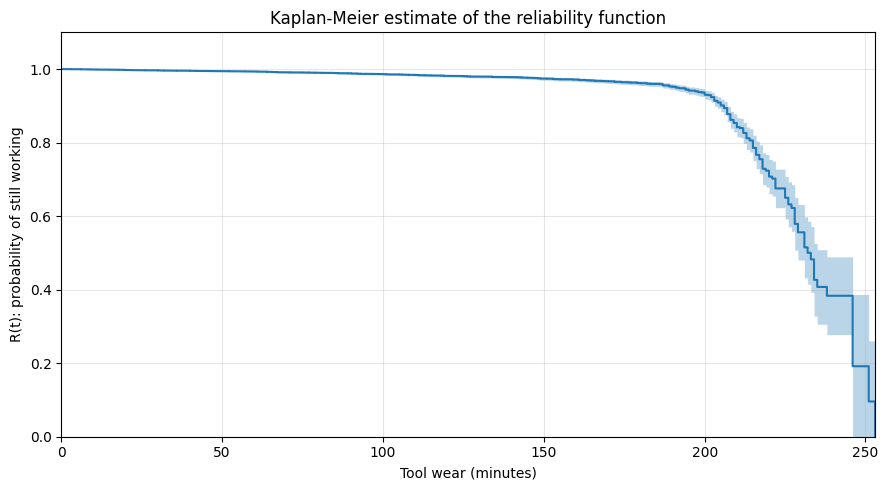

In [4]:
from reliability.Nonparametric import KaplanMeier

# failures       -> ages at which units failed
# right_censored -> ages of units still working
# print_results  -> set False here because the table has 9,880 rows
plt.figure(figsize=(9, 5))
km = KaplanMeier(
    failures=failures,
    right_censored=censored,
    print_results=False,
    show_plot=True,
)
plt.title("Kaplan-Meier estimate of the reliability function")
plt.xlabel("Tool wear (minutes)")
plt.ylabel("R(t): probability of still working")
plt.tight_layout()
plt.show()

### 👀 How to read this plot

- The curve sits **flat near 1.0 until roughly 180 minutes** of wear. Almost nothing fails before then.
- After that it **falls steeply**. Failures pile up in a narrow band of wear.
- The shaded band is the **95% confidence interval**. It widens on the right because fewer and fewer
  units survive that far, so there is less evidence out there.

That shape alone, before any model is fitted, already tells you this is **wear out** and not random
failure. If failures were random, the curve would decay smoothly from the very start.

In [5]:
# ── Read numbers off the curve ───────────────────────────────────────────────
# km.xvals holds the ages, km.SF holds the estimated reliability at each age.
# np.interp lets us query the curve at any age we like.
for age in [100, 150, 180, 200, 220, 240]:
    r = np.interp(age, km.xvals, km.SF)
    print(f"   R({age:>3} min) = {r:5.1%}   ->  {1 - r:5.1%} of tools have failed by {age} minutes")

   R(100 min) = 98.6%   ->   1.4% of tools have failed by 100 minutes
   R(150 min) = 97.4%   ->   2.6% of tools have failed by 150 minutes
   R(180 min) = 96.2%   ->   3.8% of tools have failed by 180 minutes
   R(200 min) = 93.0%   ->   7.0% of tools have failed by 200 minutes
   R(220 min) = 70.8%   ->  29.2% of tools have failed by 220 minutes
   R(240 min) = 38.3%   ->  61.7% of tools have failed by 240 minutes


## 3.2 All three estimators together

Let us plot Kaplan-Meier, Nelson-Aalen, and Rank Adjustment on the same axes to see how much the choice
actually matters.

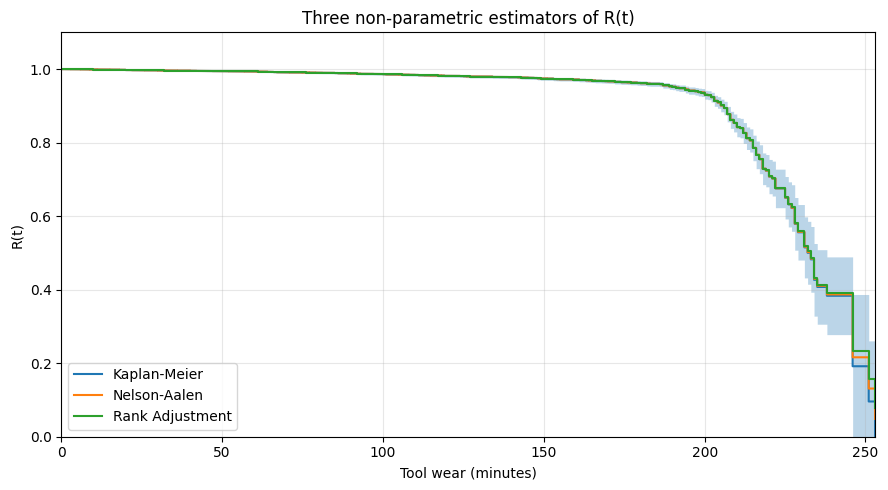

👀 The three curves lie almost on top of each other. With this much data the
   choice of estimator is not what your answer depends on.


In [6]:
from reliability.Nonparametric import NelsonAalen, RankAdjustment

plt.figure(figsize=(9, 5))

# plot_CI=False on the last two, otherwise three overlapping confidence bands
# make the figure unreadable.
KaplanMeier(failures=failures, right_censored=censored,
            print_results=False, label="Kaplan-Meier")
NelsonAalen(failures=failures, right_censored=censored,
            print_results=False, plot_CI=False, label="Nelson-Aalen")
RankAdjustment(failures=failures, right_censored=censored,
               print_results=False, plot_CI=False, label="Rank Adjustment")

plt.title("Three non-parametric estimators of R(t)")
plt.xlabel("Tool wear (minutes)")
plt.ylabel("R(t)")
plt.legend()
plt.tight_layout()
plt.show()

print("👀 The three curves lie almost on top of each other. With this much data the")
print("   choice of estimator is not what your answer depends on.")

### ✅ Strengths and ❌ limits of the non-parametric approach

| ✅ Strengths | ❌ Limits |
|---|---|
| Assumes nothing. Cannot be wrong about a distribution it never assumed | **Stops where the data stops.** It cannot tell you R(400) if nothing was observed past 253 |
| Handles censoring correctly and automatically | No compact formula. You cannot hand a planner two parameters |
| The honest first look at any dataset | Noisy in the tails, where you often care most |
| Excellent for **comparing groups** (machine A against machine B) | Cannot be plugged into a cost optimization |

> 🎓 **Rule of thumb.** Always plot the non-parametric curve first. It is your reality check for
> everything that follows.

<a id="p4"></a>
## 🟩 4. Part B: Parametric Methods

<div style="border-left:5px solid #00573F;background:#EAF3EF;padding:14px 18px;border-radius:6px">
<b>The idea in one sentence.</b> Assume the failure times follow a known distribution, estimate its two
or three parameters from the data, and from then on you have a <b>formula</b> that works at any age,
including ages you never observed.
</div>

The **Weibull** distribution is the default choice in reliability engineering, for a good reason: its
shape parameter β has a direct physical reading.

| β | Hazard | Meaning |
|---|---|---|
| β < 1 | 📉 Falling | Infant mortality |
| β = 1 | ➡️ Flat | Random failures (this is the exponential distribution) |
| β > 1 | 📈 Rising | Wear out |

The other parameter, **α (alpha)**, is the *characteristic life*: the age by which about 63.2% of units
have failed. It sets the scale.

## 4.1 Fitting a Weibull distribution

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 336/9544 (96.59919% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         487.517          25.245   440.465   539.594
     Beta         2.61203        0.114838   2.39638   2.84709 

Goodness of fit    Value
 Log-likelihood -2884.14
           AICc  5772.28
            BIC  5786.67
             AD  315.718 



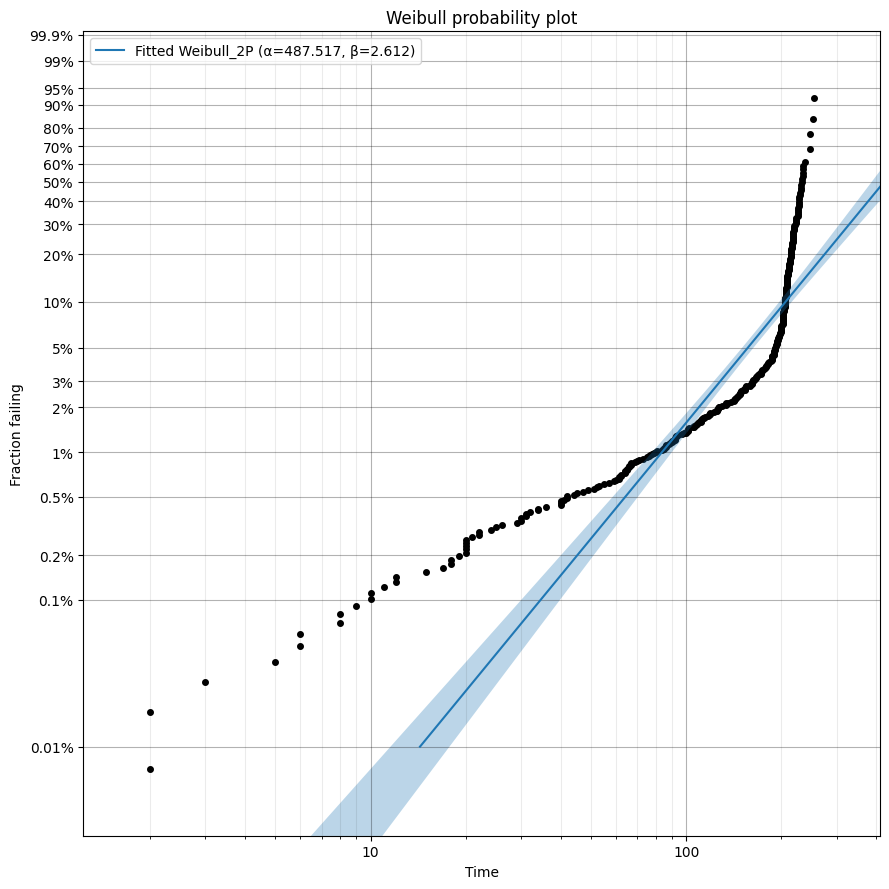

In [7]:
from reliability.Fitters import Fit_Weibull_2P

plt.figure(figsize=(7, 6))

# Note that censored units go in their own argument. The fit uses them properly:
# they contribute "this unit survived at least this long" to the likelihood.
weib = Fit_Weibull_2P(
    failures=failures,
    right_censored=censored,
    show_probability_plot=True,
    print_results=True,
)

plt.title("Weibull probability plot")
plt.tight_layout()
plt.show()

### 👀 How to read a probability plot

This is **the** diagnostic plot of reliability engineering, and it is simple to read:

- The axes are stretched so that **if the data really are Weibull, the points fall on a straight line**.
- The blue line is the fitted model. The black dots are the actual data.
- **Points on the line: good fit. Points curving away from the line: wrong model.**

Look carefully at our plot. The dots **bend away from the line**, badly, at both ends. The fitted
numbers will still print, and they will still look authoritative, but the model does not describe this
data. We come back to this in Part C, and fix it in Part D.

The **Anderson-Darling (AD)** statistic in the results table above is the same message as a number:
lower is better, and ours is very large.

In [8]:
from reliability.Distributions import Weibull_Distribution

# Build a distribution object from the fitted parameters so we can compute
# anything we like from it.
dist = Weibull_Distribution(alpha=weib.alpha, beta=weib.beta)

b10  = dist.inverse_SF(0.90)      # age at which 90% still survive
b50  = dist.inverse_SF(0.50)      # median life
mttf = dist.mean                  # mean time to failure

print(f"α  (characteristic life) : {weib.alpha:8.1f} minutes")
print(f"β  (shape)               : {weib.beta:8.2f}")
print(f"B10 life                 : {b10:8.1f} minutes")
print(f"B50 life (median)        : {b50:8.1f} minutes")
print(f"MTTF                     : {mttf:8.1f} minutes")
print(f"\n🔎 β = {weib.beta:.2f} is greater than 1, so the hazard is rising: wear out.")

α  (characteristic life) :    487.5 minutes
β  (shape)               :     2.61
B10 life                 :    206.0 minutes
B50 life (median)        :    423.7 minutes
MTTF                     :    433.1 minutes

🔎 β = 2.61 is greater than 1, so the hazard is rising: wear out.


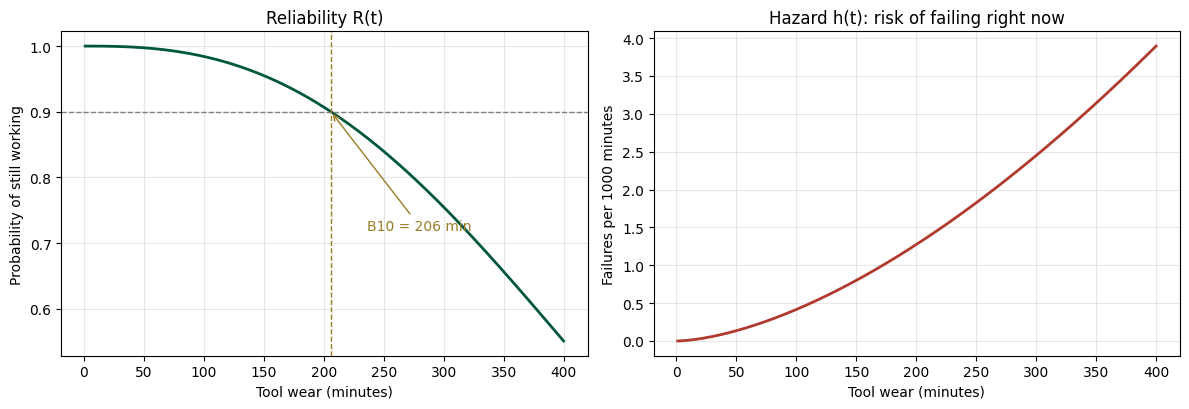

📈 The hazard curve rises. That is the visual signature of wear out, and it is
   the evidence you would put in front of a planner to justify a change interval.


In [9]:
# ── The two curves a planner asks for ────────────────────────────────────────
t = np.linspace(1, 400, 400)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# show_plot=False stops the library drawing its own figure on top of ours.
ax[0].plot(t, dist.SF(xvals=t, show_plot=False), lw=2, color="#00573F")
ax[0].axhline(0.90, ls="--", color="grey", lw=1)
ax[0].axvline(b10, ls="--", color="#9A7B26", lw=1)
ax[0].annotate(f"B10 = {b10:.0f} min", xy=(b10, 0.90), xytext=(b10 + 30, 0.72),
               color="#9A7B26", arrowprops=dict(arrowstyle="->", color="#9A7B26"))
ax[0].set_title("Reliability R(t)")
ax[0].set_xlabel("Tool wear (minutes)")
ax[0].set_ylabel("Probability of still working")

# The hazard values are small numbers, so we scale to "per 1000 minutes" to make
# the axis readable. The shape is what matters, not the units.
ax[1].plot(t, dist.HF(xvals=t, show_plot=False) * 1000, lw=2, color="#B03A2E")
ax[1].set_title("Hazard h(t): risk of failing right now")
ax[1].set_xlabel("Tool wear (minutes)")
ax[1].set_ylabel("Failures per 1000 minutes")

plt.tight_layout()
plt.show()

print("📈 The hazard curve rises. That is the visual signature of wear out, and it is")
print("   the evidence you would put in front of a planner to justify a change interval.")

<a id="p5"></a>
## 🔍 5. Part C: Do the Two Agree?

Here is the single most useful habit in life data analysis:

<div style="border-left:5px solid #B8860B;background:#FDF6E3;padding:14px 18px;border-radius:6px">
🎯 <b>Plot your fitted parametric curve on top of the non-parametric one.</b> The non-parametric curve
is the data. The parametric curve is your model. If they do not lie on top of each other, your model is
wrong, no matter how confident the parameter table looks.
</div>

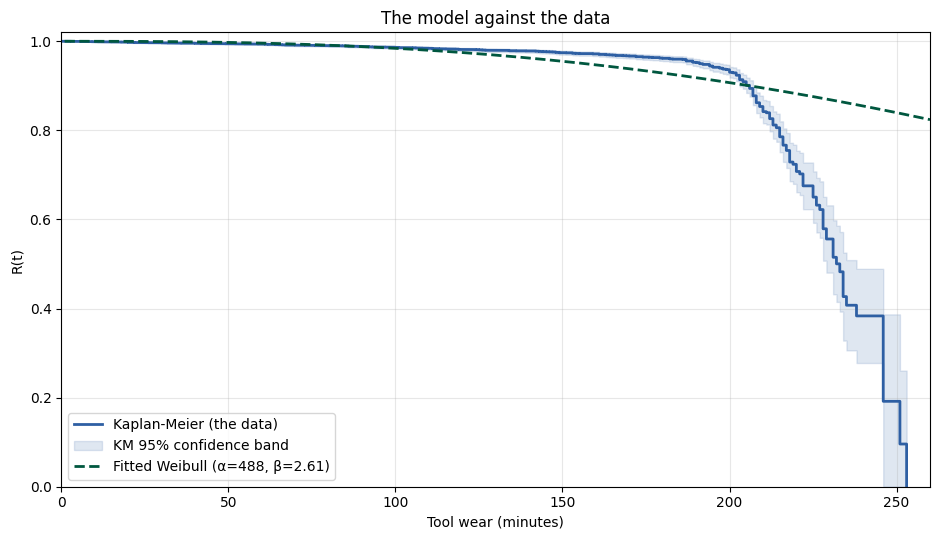

In [10]:
plt.figure(figsize=(9.5, 5.5))

# 🟦 The data, with no assumptions: the Kaplan-Meier estimate
plt.plot(km.xvals, km.SF, color="#2E5FA3", lw=2, label="Kaplan-Meier (the data)")
plt.fill_between(km.xvals, km.SF_lower, km.SF_upper,
                 color="#2E5FA3", alpha=0.15, label="KM 95% confidence band")

# 🟩 The fitted model
t = np.linspace(1, 260, 400)
plt.plot(t, dist.SF(xvals=t, show_plot=False), color="#00573F", lw=2, ls="--",
         label=f"Fitted Weibull (α={weib.alpha:.0f}, β={weib.beta:.2f})")

plt.xlim(0, 260)
plt.ylim(0, 1.02)
plt.title("The model against the data")
plt.xlabel("Tool wear (minutes)")
plt.ylabel("R(t)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

### 🚩 The verdict

They do **not** agree. The fitted Weibull declines steadily from the very start, while the real data
stays flat and then falls off a cliff. The model is:

- too pessimistic early (it predicts failures that never happen before 150 minutes),
- too optimistic late (it misses how suddenly failures arrive after 200 minutes).

So a single Weibull is the wrong model here. **Why?**

Because the AI4I data does not contain one failure mode. It contains **five**, and we pooled them all
into a single "machine failure" flag:

| Flag | Failure mode |
|---|---|
| `TWF` | Tool wear failure |
| `HDF` | Heat dissipation failure |
| `PWF` | Power failure |
| `OSF` | Overstrain failure |
| `RNF` | Random failure |

One distribution describes **one** physical mechanism. Ask it to describe five mechanisms at once and
it fits none of them. This is the most common mistake in industrial Weibull analysis, and the
probability plot catches it every time.

In [11]:
# ── How many failures of each mode? ──────────────────────────────────────────
for mode, name in [("TWF", "Tool wear failure"),
                   ("HDF", "Heat dissipation failure"),
                   ("PWF", "Power failure"),
                   ("OSF", "Overstrain failure"),
                   ("RNF", "Random failure")]:
    print(f"   {mode}  {name:<26} {int(life[mode].sum()):>4}")

print(f"\n   Pooled 'Machine failure' flag      {int(life['Machine failure'].sum()):>4}")
print("\n(The modes sum to more than the flag because one event can trip several modes.)")

   TWF  Tool wear failure            46
   HDF  Heat dissipation failure    115
   PWF  Power failure                92
   OSF  Overstrain failure           98
   RNF  Random failure               19

   Pooled 'Machine failure' flag       336

(The modes sum to more than the flag because one event can trip several modes.)


<a id="p6"></a>
## 🤖 6. Part D: Letting the Library Pick the Model

You do not have to guess the distribution. `Fit_Everything` fits every distribution the library knows,
ranks them by goodness of fit, and shows you the comparison.

> ⏱️ This cell takes roughly 15 seconds. It is fitting about fifteen models.

In [12]:
from reliability.Fitters import Fit_Everything

everything = Fit_Everything(
    failures=failures,
    right_censored=censored,
    sort_by="BIC",                 # lower BIC is a better fit, penalized for complexity
    print_results=True,
    show_histogram_plot=False,     # turned off to keep the output compact
    show_PP_plot=False,
    show_probability_plot=False,
    show_best_distribution_probability_plot=False,
)

print(f"\n🏆 Best fitting model: {everything.best_distribution_name}")

Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 336/9544 (96.59919% right censored) 

   Distribution   Alpha    Beta  Gamma Alpha 1  Beta 1 Alpha 2  Beta 2 Proportion 1 DS      Mu   Sigma      Lambda  Log-likelihood    AICc     BIC      AD optimizer
     Weibull_CR                        2640.04 1.28843 238.325 17.7746                                                    -2619.86 5247.72 5276.51 61.9856       TNC
Weibull_Mixture                        519.785 1.33844 236.136 17.9659      0.14184                                       -2620.74 5251.48 5287.46   53.55       TNC
      Gumbel_2P                                                                        281.156 38.0505                    -2760.41 5524.82 5539.21 155.987       TNC
      Normal_2P                                                                        324.521 97.7353                    -2807.52 5619.05 5633.44 246.199       TNC
     Weibull_2P 487.517 2.61203                             

### 🎉 Look at what won

The library ranked **`Weibull_CR`** first, with **`Weibull_Mixture`** a close second. Both of these are
**multi-mode models**:

- **`Weibull_CR`** is a **competing risks** model: several failure mechanisms racing each other, and
  whichever gets there first kills the unit.
- **`Weibull_Mixture`** assumes the population is a blend of sub-populations with different lives.

The plain `Weibull_2P` we fitted in Part B sits far down the list.

**The software discovered on its own what the probability plot was telling us**: this data has more
than one failure mode. That is a satisfying result, and it is also a warning. `Fit_Everything` ranks
models by a number. It is your job to ask whether the winning model makes **physical** sense. Here it
does, because we know from the data dictionary that there really are five failure modes.

## 6.1 The proper fix: analyze one failure mode at a time

The cleanest approach is not a fancier model. It is a better question. Instead of asking *"when does
the machine fail?"*, ask *"when does the **tool wear out**?"*

The trick is in the censoring:

<div style="border-left:5px solid #2E5FA3;background:#EDF2FA;padding:14px 18px;border-radius:6px">
When you study tool wear failure, a unit that failed from a <b>power fault</b> is not a tool wear
failure. It is a unit that was <b>removed from risk</b> before tool wear could kill it. That is exactly
the definition of a <b>censored</b> observation. So every non-TWF row becomes censored data.
</div>

⚙️  Tool wear failures :     46
⏹️  Right censored     :  9,834
Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 46/9834 (99.53441% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         246.889         2.27723   242.466   251.393
     Beta          23.637          1.7616   20.4247   27.3546 

Goodness of fit    Value
 Log-likelihood -292.911
           AICc  589.823
            BIC  604.218
             AD  80.3239 



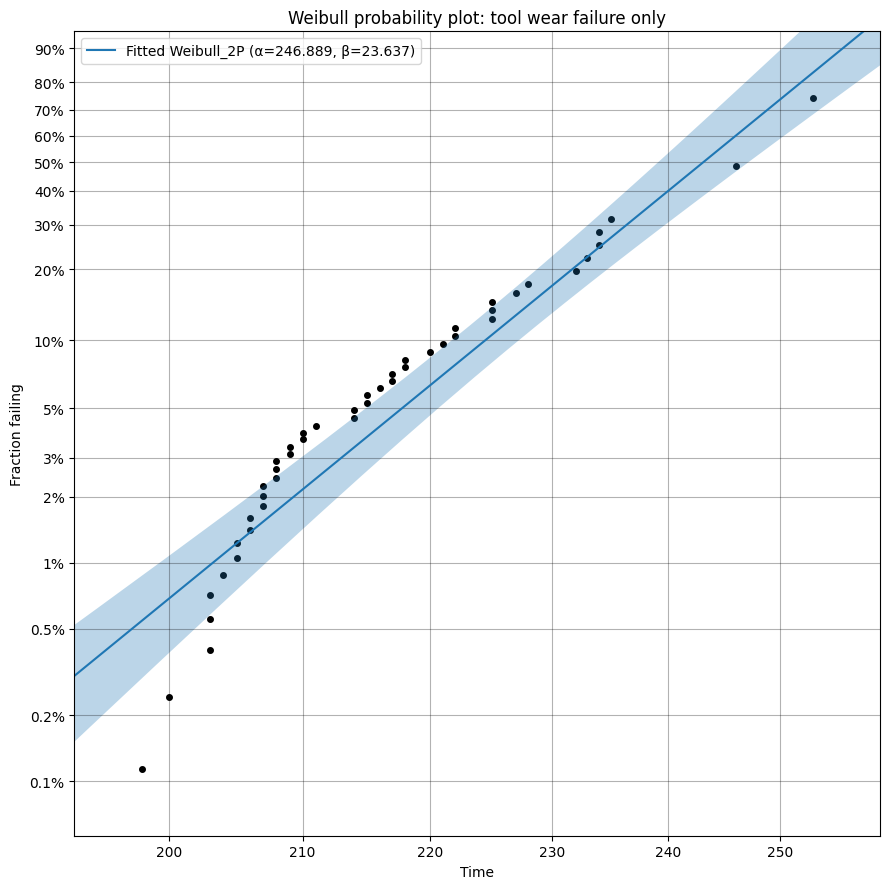

In [13]:
# ── Competing risks done by hand: tool wear failure only ─────────────────────
# failures       -> units that failed specifically from tool wear
# right_censored -> EVERY other unit, whether it survived to the end of the study
#                   or was removed by a different failure mode
twf_failures = life.loc[life["TWF"] == 1, "Tool wear [min]"].astype(float).values
twf_censored = life.loc[life["TWF"] == 0, "Tool wear [min]"].astype(float).values

print(f"⚙️  Tool wear failures : {len(twf_failures):>6,}")
print(f"⏹️  Right censored     : {len(twf_censored):>6,}")

plt.figure(figsize=(7, 6))
twf = Fit_Weibull_2P(
    failures=twf_failures,
    right_censored=twf_censored,
    show_probability_plot=True,
    print_results=True,
)
plt.title("Weibull probability plot: tool wear failure only")
plt.tight_layout()
plt.show()

In [14]:
# ── Compare the pooled fit with the mode-specific fit ────────────────────────
twf_dist = Weibull_Distribution(alpha=twf.alpha, beta=twf.beta)

rows = [
    ("α  characteristic life (min)", weib.alpha,               twf.alpha),
    ("β  shape",                      weib.beta,                twf.beta),
    ("B10 life (min)",                b10,                      twf_dist.inverse_SF(0.90)),
    ("Anderson-Darling (lower=better)", weib.AD,                twf.AD),
]

print(f"{'':<34}{'Pooled (5 modes)':>18}{'Tool wear only':>18}")
print("=" * 70)
for label, a, b in rows:
    print(f"{label:<34}{a:>18.2f}{b:>18.2f}")
print("=" * 70)

                                    Pooled (5 modes)    Tool wear only
α  characteristic life (min)                  487.52            246.89
β  shape                                        2.61             23.64
B10 life (min)                                205.98            224.47
Anderson-Darling (lower=better)               315.72             80.32


### 🧠 What changed, in plain terms

- **β jumped from about 2.6 to above 20.** A shape that large means an almost *deterministic* wear-out:
  the tool is reliable, then it fails within a narrow window of wear. That is exactly what tool wear
  physics predicts, and it was completely invisible in the pooled fit.
- **Anderson-Darling dropped sharply**, and the points on the new probability plot follow the line
  closely.
- **The maintenance answer became usable.** "Wear out" was vague. "Almost nothing fails before 200
  minutes of wear, and almost everything has failed by 250" is something you can schedule around.

> 🎓 **The lesson.** Reliability software will fit a distribution to anything and print confident
> looking numbers. The probability plot and the goodness-of-fit statistic are what stand between a
> fitted model and a defensible one. **Look at the plot first, every time.**

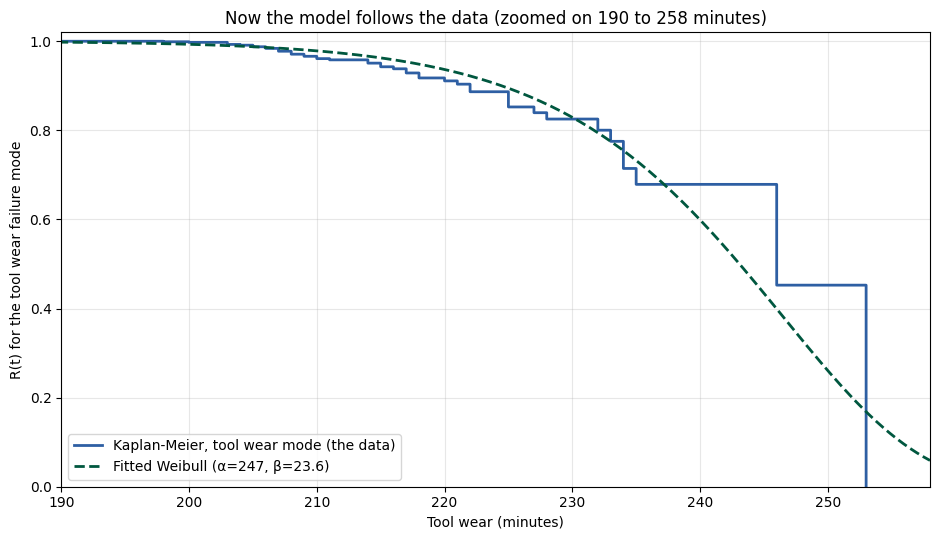

✅ The dashed model now tracks the blue data. Compare this with the plot in Part C.


In [15]:
# ── One more reality check: the mode-specific model against its own data ─────
plt.figure(figsize=(9.5, 5.5))

# Non-parametric estimate for the tool wear failure mode
km_twf = KaplanMeier(failures=twf_failures, right_censored=twf_censored,
                     print_results=False, show_plot=False)

plt.plot(km_twf.xvals, km_twf.SF, color="#2E5FA3", lw=2,
         label="Kaplan-Meier, tool wear mode (the data)")

t2 = np.linspace(180, 258, 300)
plt.plot(t2, twf_dist.SF(xvals=t2, show_plot=False), color="#00573F", lw=2, ls="--",
         label=f"Fitted Weibull (α={twf.alpha:.0f}, β={twf.beta:.1f})")

# Zoom on the wear range where tool wear failures actually happen. Nothing at all
# occurs before about 190 minutes, so plotting from zero would waste the whole axis.
plt.xlim(190, 258)
plt.ylim(0, 1.02)
plt.title("Now the model follows the data (zoomed on 190 to 258 minutes)")
plt.xlabel("Tool wear (minutes)")
plt.ylabel("R(t) for the tool wear failure mode")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("✅ The dashed model now tracks the blue data. Compare this with the plot in Part C.")

<a id="p7"></a>
## 💰 7. Part E: Turning the Model into a Decision

A fitted distribution is not the deliverable. **A decision is.**

Here is the classic one. If we replace the tool **too early** we waste good tool life. If we replace it
**too late** it fails in service, and an unplanned failure costs far more than a planned change.

There is an optimal replacement age in between, and because we now have a parametric model we can
compute it. This is something the non-parametric curve **cannot** do for us.

`reliability` has this built in.

Results from optimal_replacement_time:
Cost model assuming as good as new replacement (q=0):
The minimum cost per unit time is 0.01 
The optimal replacement time is 195.48


<Figure size 900x500 with 0 Axes>

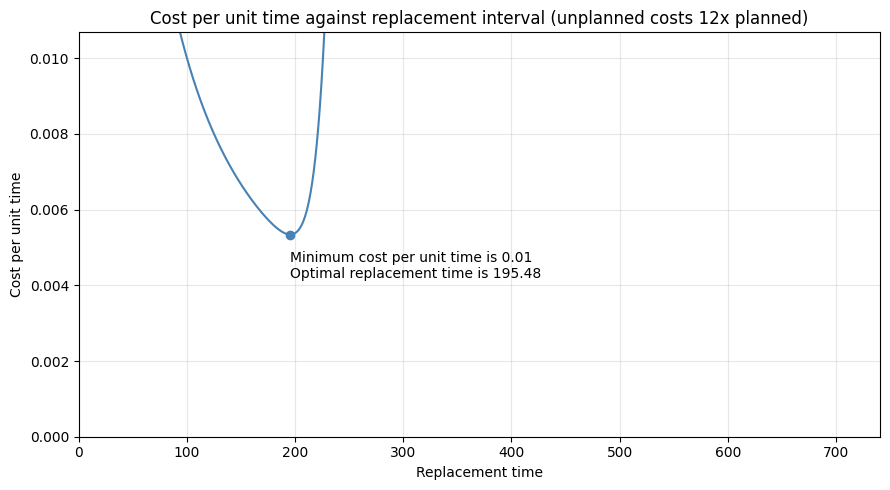


🎯 Replace the tool at about 195 minutes of wear.
   For comparison, the B10 life is 224 minutes.


In [16]:
from reliability.Repairable_systems import optimal_replacement_time

# cost_PM : cost of a PLANNED (preventive) replacement
# cost_CM : cost of an UNPLANNED (corrective) replacement after a failure
# q=0     : the replacement restores the tool to "as good as new"
COST_PLANNED   = 1     # normalize the planned change to 1 cost unit
COST_UNPLANNED = 12    # an unplanned failure costs 12 times as much

plt.figure(figsize=(9, 5))
ort = optimal_replacement_time(
    cost_PM=COST_PLANNED,
    cost_CM=COST_UNPLANNED,
    weibull_alpha=twf.alpha,     # use the GOOD model from Part D
    weibull_beta=twf.beta,
    q=0,
    show_time_plot=True,
    show_ratio_plot=False,
    print_results=True,
)
plt.title(f"Cost per unit time against replacement interval "
          f"(unplanned costs {COST_UNPLANNED}x planned)")
plt.tight_layout()
plt.show()

print(f"\n🎯 Replace the tool at about {ort.ORT:.0f} minutes of wear.")
print(f"   For comparison, the B10 life is {twf_dist.inverse_SF(0.90):.0f} minutes.")

### 📊 How sensitive is that answer to the cost ratio?

Nobody knows the true cost of an unplanned failure to the nearest riyal. So the useful question is not
"what is the optimum?" but **"how much does the optimum move when my cost estimate is wrong?"**

In [17]:
# ── Sweep the cost ratio and watch the recommended interval move ─────────────
print(f"{'Unplanned : planned':>21}{'Optimal interval (min)':>26}")
print("=" * 47)

for ratio in [2, 3, 5, 10, 20, 50, 100]:
    result = optimal_replacement_time(
        cost_PM=1, cost_CM=ratio,
        weibull_alpha=twf.alpha, weibull_beta=twf.beta, q=0,
        show_time_plot=False, show_ratio_plot=False, print_results=False,
    )
    print(f"{ratio:>18} : 1{result.ORT:>26.0f}")

print("=" * 47)
print("\n🧠 Notice how little the answer moves. Because β is very large, the failure")
print("   window is narrow, so the optimal interval is stable even when the cost")
print("   estimate is off by a factor of ten. That is a genuinely useful thing to be")
print("   able to tell a manager who is arguing about the cost figure.")

  Unplanned : planned    Optimal interval (min)
                 2 : 1                       216
                 3 : 1                       210
                 5 : 1                       204
                10 : 1                       197
                20 : 1                       191
                50 : 1                       183
               100 : 1                       178

🧠 Notice how little the answer moves. Because β is very large, the failure
   window is narrow, so the optimal interval is stable even when the cost
   estimate is off by a factor of ten. That is a genuinely useful thing to be
   able to tell a manager who is arguing about the cost figure.


<a id="p8"></a>
## ⚖️ 8. Summary: Which Method, When

### 🟦 Non-parametric (Kaplan-Meier, Nelson-Aalen, Rank Adjustment)

| | |
|---|---|
| ✅ **Use it** | Always, as your first look. To compare two groups. When you do not trust any distributional assumption |
| ❌ **Do not use it** | To extrapolate beyond the observed data. To feed a cost optimization |
| 🎯 **Gives you** | An honest picture of the data as it is |

### 🟩 Parametric (Weibull, Lognormal, Gamma, ...)

| | |
|---|---|
| ✅ **Use it** | To extrapolate. To compute B10, MTTF, optimal intervals. To report two numbers instead of a curve |
| ❌ **Do not use it** | Before you have checked the probability plot. On pooled failure modes |
| 🎯 **Gives you** | A formula you can plan and optimize with |

### 🔁 The workflow to remember

```
1.  Split the data into failures and censored units.  Get the censoring right.
2.  Plot the non-parametric curve.        <- the data, with no assumptions
3.  Fit a parametric model.
4.  Overlay 3 on 2 and look at the probability plot.   <- the reality check
5.  If they disagree, ask WHY.  Usually: mixed failure modes.
6.  Split by failure mode, refit, and check again.
7.  Only now use the model to make a decision.
```

Steps 4 and 5 are the ones people skip, and they are the ones that matter.

<a id="p9"></a>
## ✍️ 9. Exercises

### 1️⃣ The other failure modes

Repeat the Part D analysis for `HDF`, `PWF`, and `OSF`, one at a time.

- Which modes show wear out (β > 1) and which look random (β close to 1)?
- What different maintenance action does each imply? Remember the table in Section 1.

### 2️⃣ Non-parametric group comparison

The `Type` column records the product quality grade: `L`, `M`, or `H`.

- Plot a Kaplan-Meier curve for each grade on the same axes.
- Do the curves separate? What would you conclude, and how confident are you given the confidence
  bands?
- This is a question non-parametric methods answer well and parametric methods complicate.

### 3️⃣ Why censoring matters

Rerun the Part B Weibull fit **three ways**:

1. Correctly, with `right_censored=censored` (what we did).
2. Deleting the censored units entirely, so only the 336 failures are used.
3. Treating every censored unit as if it had failed.

Compare α, β, and B10 across the three. Which direction does each error push the answer, and by how
much? Write one sentence you could say to a colleague who asks "why can't I just drop the ones that
didn't fail?"

### 4️⃣ Choosing the interval

Using the tool wear model from Part D:

- Plot cost per unit time against replacement interval for cost ratios of 3, 12, and 50 on one figure.
- Mark the optimum on each.
- Your plant manager says an unplanned tool failure costs "somewhere between 5 and 30 times" a planned
  change. What single interval would you recommend, and how would you defend it?

### 5️⃣ Fit_Everything, carefully

Run `Fit_Everything` on the **tool wear only** data from Part D.

- Which distribution wins now?
- Is it much better than the plain Weibull, or only slightly?
- When is it worth accepting a more complicated model for a small improvement in fit? Give a reason
  that an engineer, not a statistician, would accept.

<a id="p10"></a>
## 📚 10. What Else Is in the Library

We used a small part of `reliability`. Here is what else is there, so you know where to look.

| Module | What it does |
|---|---|
| `reliability.Fitters` | Fit any distribution. Includes mixtures, competing risks, and zero-inflated models |
| `reliability.Distributions` | Distribution objects: `SF`, `CDF`, `HF`, `mean`, `quantile` and more |
| `reliability.Nonparametric` | Kaplan-Meier, Nelson-Aalen, Rank Adjustment |
| `reliability.Repairable_systems` | Optimal replacement time, mean cumulative function, ROCOF, reliability growth |
| `reliability.ALT_fitters` | Accelerated life testing models (temperature, voltage, dual stress) |
| `reliability.PoF` | Physics of failure: fracture mechanics, creep, fatigue |
| `reliability.Reliability_testing` | Test planning, sample size, sequential testing, one sample proportion |
| `reliability.Convert_data` | Move between the formats reliability data arrives in |
| `reliability.Other_functions` | Stress-strength interference, distribution explorer, similar distributions |

### 🔗 Links

| Resource | URL |
|---|---|
| Documentation | https://reliability.readthedocs.io/en/latest/ |
| Quickstart for reliability engineers | https://reliability.readthedocs.io/en/latest/Quickstart%20for%20reliability%20engineers.html |
| API reference | https://reliability.readthedocs.io/en/latest/API/index.html |
| Source | https://github.com/MatthewReid854/reliability |

### 🗂️ Dataset

**AI4I 2020 Predictive Maintenance Dataset**, UCI Machine Learning Repository (dataset 601). Introduced
in Matzka, S. "Explainable Artificial Intelligence for Predictive Maintenance Applications" (2020).

---

<div style="background:#00573F;padding:16px 22px;border-radius:8px;color:#ffffff">
<b>ISE 518 &mdash; Data Analytics for Reliability and Maintenance</b><br>
King Fahd University of Petroleum and Minerals<br>
<span style="opacity:.85">All data is read from a public URL, so this notebook needs only an internet connection to run.</span>
</div>